# Testing

In [16]:
import sys
import os

sys.path.append(os.path.abspath(".."))
#IMPORTS
import matplotlib.pyplot as plt
import scipy.io as sio
import pandas as pd
import numpy as np
from sklearn.decomposition import FastICA
from src.visualizacion import *
from src.evaluacion import *
from src.metricas import *
from src.preprocesamiento import *
from src.io_utils import *
from src.sobi import *
from scipy import signal
#VARIABLES
fs=1000
window_size=200
salto=50

## Load data

In [17]:
mat=load_mat("C:/Users/34648/Desktop/Clases/4_GITT/TFG/OPENICPSR/TR2_postTMR_32chanEMG.mat")

## Preprocesing

In [18]:
#Preprocesado
emg = find_movement_rep(mat, "indexFlex", rep=1)[0]


emg = eliminar_continua(emg)
emg = eliminar_outiliers(emg, k=8)
emg = escalar_canales(emg, metodo="rms")



s1 = emg[:, 13]
s2 = emg[:, 18]

## Generacion señales

In [ ]:
# Ejemplo: coger una repetición de un movimiento real
X1, key1 = find_movement_rep(mat, movement="HandOpen", rep=1)
X2, key2 = find_movement_rep(mat, movement="noMotion", rep=1)  # o otro movimiento

print("Señal 1 extraída de:", key1)
print("Señal 2 extraída de:", key2)

ch_s1 = 3
ch_s2 = 20

u1 = eliminar_continua(X1[:, ch_s1].astype(float))
u2_raw = eliminar_continua(X1[:, ch_s2].astype(float))  # también puedes cogerlo de otro movimiento

#Longitudes
N = min(len(u1), len(u2_raw))
u1 = u1[:N]
u2_raw = u2_raw[:N]
N = len(u1)
t = np.arange(N) / fs

m1 = np.zeros(N)
m2 = np.zeros(N)

# ejemplo por bloques de 0.5 s
bloque = int(0.2 * fs)
bloque = int(0.2 * fs)
bloque2 = int(0.2 * fs)
# patrón:
# 0: ninguno
# 1: solo s1
# 2: solo s2
# 3: ambos
patron = [0, 1, 2,1, 3, 2, 1, 2, 3, 0,2, 3,1]

for i, estado in enumerate(patron):
    a = i * bloque
    a2= i * bloque2
    b = min((i + 1) * bloque, N)
    b2= min((i + 1) * bloque2, N)
    if estado == 1:
        m1[a:b] = 1.0
    elif estado == 2:
        m2[a2:b2] = 1.0
    elif estado == 3:
        m1[a:b] = 1.0
        m2[a2:b2] = 1.0


#CONSTRUCCION DE SEÑALES

s1 = m1 * u1
s2 = m2 * u2_raw

#RETARDOS DE S2
tau_ms = 10
tau = int(fs * tau_ms / 1000)

s2_delayed = np.zeros_like(s2)

if tau < len(s2):
    s2_delayed[tau:] = s2[:-tau]

#MEZCLAS
beta = 0.4
noise_std = 0.0

rng = np.random.default_rng(0)
n1 = noise_std * rng.standard_normal(len(s1))
n2 = noise_std * rng.standard_normal(len(s1))

c1 = 1.0 * s1 + beta * s2_delayed + n1
c2 = 0.01 * s1 + 1.0 * s2 + n2

X_mix = np.column_stack([c1, c2])
S_true = np.column_stack([s1, s2_delayed])

Señal 1 extraída de: HandOpen_1.DAQ_DATA
Señal 2 extraída de: NoMotion_1.DAQ_DATA


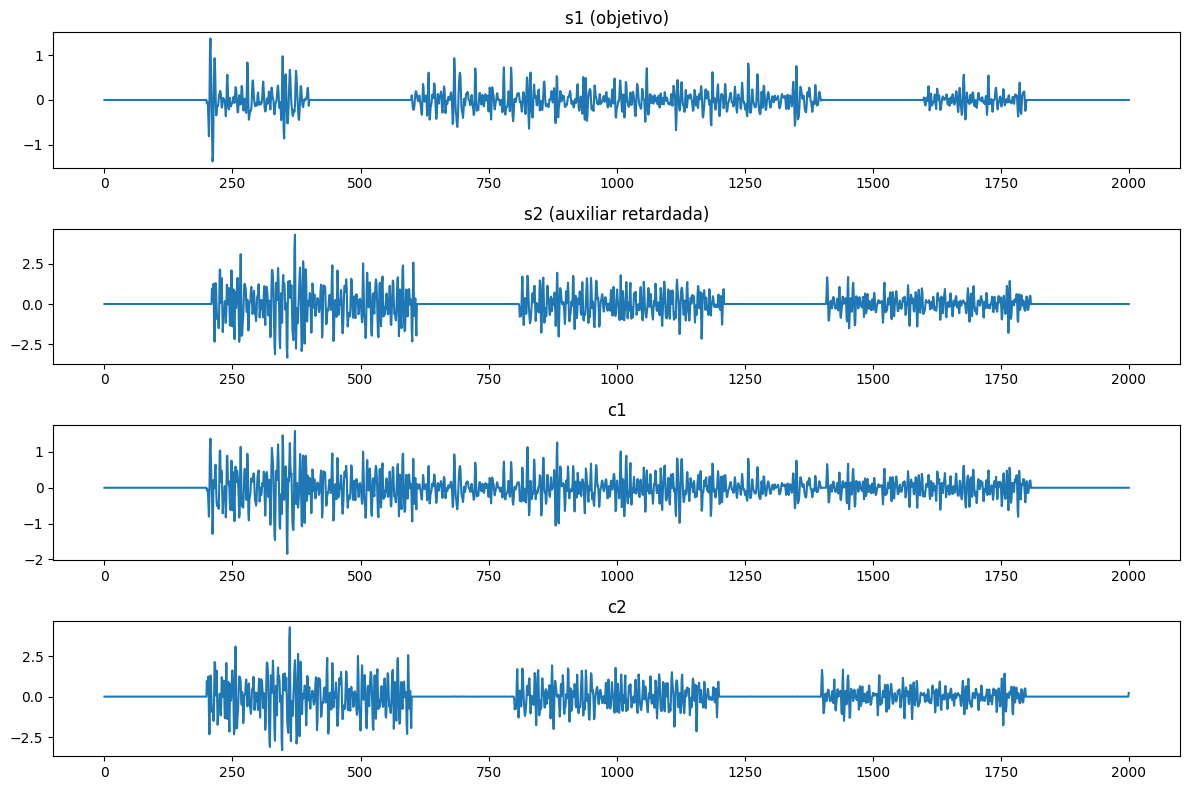

In [20]:
plt.figure(figsize=(12, 8))

plt.subplot(4, 1, 1)
plt.plot(s1)
plt.title("s1 (objetivo)")

plt.subplot(4, 1, 2)
plt.plot(s2_delayed)
plt.title("s2 (auxiliar retardada)")

plt.subplot(4, 1, 3)
plt.plot(c1)
plt.title("c1")

plt.subplot(4, 1, 4)
plt.plot(c2)
plt.title("c2")

plt.tight_layout()
plt.show()

## Test caso óptimo (ICA)

- No ruido 
- $\tau =0 ms$

Matriz de mezcla A:
[[1.   0.9 ]
 [0.01 1.  ]]

=== Resultados ===
 method source     corr  corr_rms  rms_true  rms_est  rms_rel_error  rel_mae_rms_env
FastICA     s1 0.999435  0.999810  0.181043      1.0       4.523543         4.554769
FastICA     s2 1.000000  1.000000  0.656354      1.0       0.523567         0.523882
   SOBI     s1 0.998901  0.999627  0.181043      1.0       4.523543         4.566758
   SOBI     s2 0.999919  0.999963  0.656354      1.0       0.523567         0.526176

=== Comparación respecto a s1 ===
 method     corr  corr_rms  rms_true  rms_est  rms_rel_error  rel_mae_rms_env
FastICA 0.999435  0.999810  0.181043      1.0       4.523543         4.554769
   SOBI 0.998901  0.999627  0.181043      1.0       4.523543         4.566758


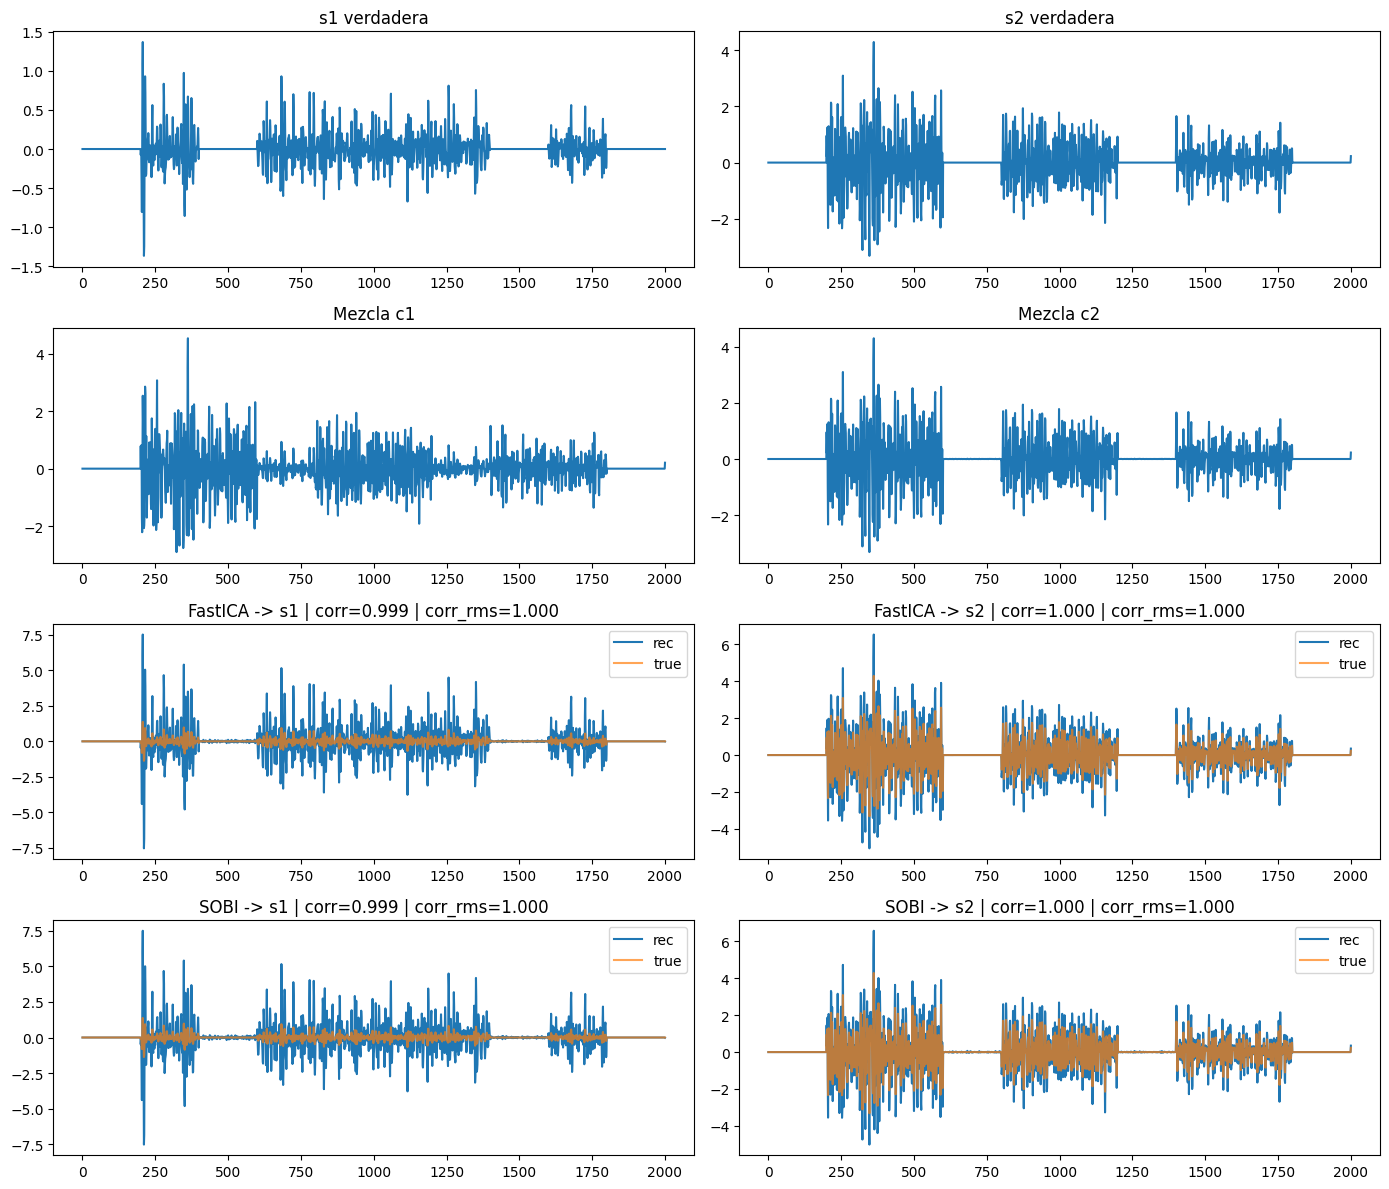

In [21]:

#evaluate_method esta definido en evaluacion.py

s1 = np.asarray(s1).ravel().astype(float)
s2 = np.asarray(s2).ravel().astype(float)

N = min(len(s1), len(s2))
s1 = s1[:N]
s2 = s2[:N]

S_true = np.column_stack([s1, s2])

#PARAMETROS
fs = 1000
window_ms = 150
step_ms = 50

beta = 0.9
a11 = 1
a12 = beta
a21 = 0.01
a22 = 1.0
noise_std = 0.0
seed = 0

rng = np.random.default_rng(seed)
n = noise_std * rng.standard_normal((N, 2))

A = np.array([
    [a11, a12],
    [a21, a22]
])

X_clean = S_true @ A.T
X = X_clean + n

print("Matriz de mezcla A:")
print(A)


#FASTICA
S_fastica, W_fastica = run_fastica(X, n_components=2, random_state=0)
df_fastica, S_fastica_eval, env_fastica = evaluate_method(
    "FastICA", S_fastica, S_true,
    fs=fs, window_ms=window_ms, step_ms=step_ms
)

#SOBI
lags = [1, 2, 3, 5, 8, 12, 16, 20, 25, 30]
S_sobi, W_sobi = sobi(X, n_sources=2, delays=lags)
df_sobi, S_sobi_eval, env_sobi = evaluate_method(
    "SOBI", S_sobi, S_true,
    fs=fs, window_ms=window_ms, step_ms=step_ms
)


#GUARDAR RESULTADOS
df_results = pd.concat([df_fastica, df_sobi], ignore_index=True)

print("\n=== Resultados ===")
print(df_results.to_string(index=False))

#RESUMEN PARA S1
df_s1 = df_results[df_results["source"] == "s1"].copy()
print("\n=== Comparación respecto a s1 ===")
print(df_s1[[
    "method", "corr", "corr_rms", "rms_true", "rms_est",
    "rms_rel_error", "rel_mae_rms_env"
]].to_string(index=False))

###################################################
#Graficas
num_samples_plot = min(4000, N)
t = np.arange(num_samples_plot)

plt.figure(figsize=(14, 12))

plt.subplot(4, 2, 1)
plt.plot(t, s1[:num_samples_plot])
plt.title("s1 verdadera")

plt.subplot(4, 2, 2)
plt.plot(t, s2[:num_samples_plot])
plt.title("s2 verdadera")

plt.subplot(4, 2, 3)
plt.plot(t, X[:num_samples_plot, 0])
plt.title("Mezcla c1")

plt.subplot(4, 2, 4)
plt.plot(t, X[:num_samples_plot, 1])
plt.title("Mezcla c2")

plt.subplot(4, 2, 5)
plt.plot(t, S_fastica_eval[:num_samples_plot, 0], label="rec")
plt.plot(t, s1[:num_samples_plot], alpha=0.7, label="true")
plt.title(
    f"FastICA -> s1 | corr={safe_corr(S_fastica_eval[:,0], s1):.3f} | "
    f"corr_rms={env_fastica['s1']['corr_rms']:.3f}"
)
plt.legend()

plt.subplot(4, 2, 6)
plt.plot(t, S_fastica_eval[:num_samples_plot, 1], label="rec")
plt.plot(t, s2[:num_samples_plot], alpha=0.7, label="true")
plt.title(
    f"FastICA -> s2 | corr={safe_corr(S_fastica_eval[:,1], s2):.3f} | "
    f"corr_rms={env_fastica['s2']['corr_rms']:.3f}"
)
plt.legend()

plt.subplot(4, 2, 7)
plt.plot(t, S_sobi_eval[:num_samples_plot, 0], label="rec")
plt.plot(t, s1[:num_samples_plot], alpha=0.7, label="true")
plt.title(
    f"SOBI -> s1 | corr={safe_corr(S_sobi_eval[:,0], s1):.3f} | "
    f"corr_rms={env_sobi['s1']['corr_rms']:.3f}"
)
plt.legend()

plt.subplot(4, 2, 8)
plt.plot(t, S_sobi_eval[:num_samples_plot, 1], label="rec")
plt.plot(t, s2[:num_samples_plot], alpha=0.7, label="true")
plt.title(
    f"SOBI -> s2 | corr={safe_corr(S_sobi_eval[:,1], s2):.3f} | "
    f"corr_rms={env_sobi['s2']['corr_rms']:.3f}"
)
plt.legend()

plt.tight_layout()
plt.show()



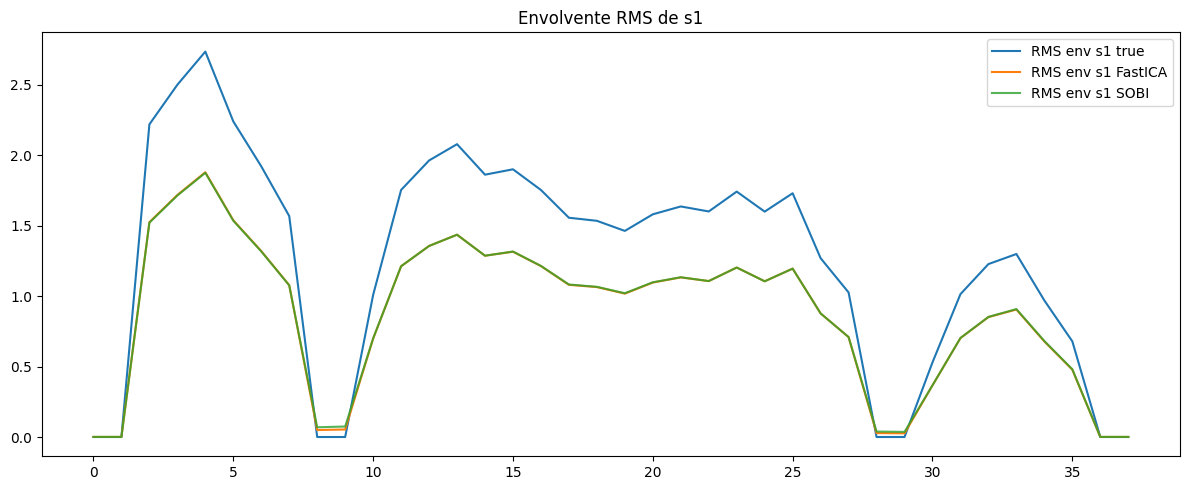

In [22]:
#Grafica de envolventes RMS
plt.figure(figsize=(12, 5))
plt.plot(8*env_fastica["s1"]["env_true"], label="RMS env s1 true")
plt.plot(env_fastica["s1"]["env_est"], label="RMS env s1 FastICA")
plt.plot(env_sobi["s1"]["env_est"], label="RMS env s1 SOBI", alpha=0.8)
plt.title("Envolvente RMS de s1")
plt.legend()
plt.tight_layout()
plt.show()

### RUIDO + retardo



### Barrido de parámetros con ruido

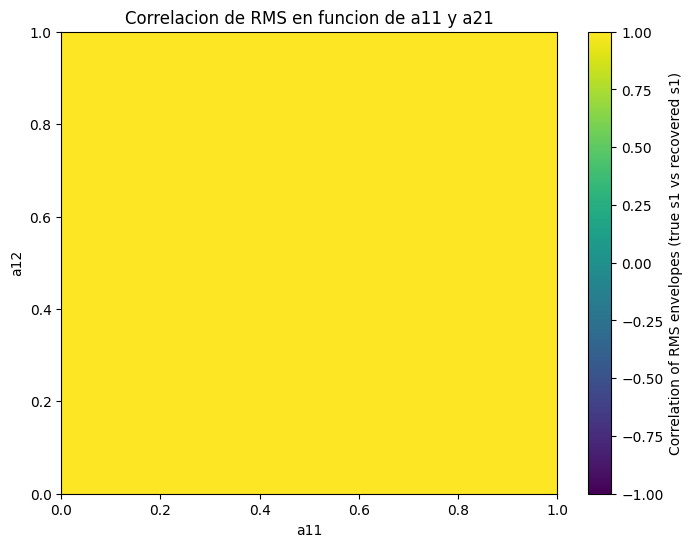

In [23]:
s1 = np.asarray(s1)
s2 = np.asarray(s2)

N = min(len(s1), len(s2))
s1 = s1[:N]
s2 = s2[:N]

S_true = np.column_stack([s1, s2])


#Parametros
a11_values = np.linspace(0, 1, 50)
a21_values = np.linspace(0, 1, 50)

corr_map = np.zeros((len(a21_values), len(a11_values)))

noise_std = 0.00
window = 200  


#SIMULAR
for i, a21 in enumerate(a21_values):
    for j, a11 in enumerate(a11_values):

        A = np.array([
            [a11,   a12],
            [0.01, 1  ]
        ])

        X = S_true @ A.T
        noise = noise_std * np.random.randn(*X.shape)
        X = X + noise

        # ICA
        ica = FastICA(n_components=2, random_state=0)
        S_est = ica.fit_transform(X)

        # Alinear
        S_est = align_sources(S_est, S_true)

        # RMS envelope de la s1 original y estimada
        rms_orig_env = rms_envelope(s1, window)
        rms_est_env  = rms_envelope(S_est[:, 0], window)

        # Correlación entre envolventes RMS
        corr = safe_corr(rms_orig_env, rms_est_env)

        corr_map[i, j] = corr


# ==========================================
# Heatmap
# ==========================================
plt.figure(figsize=(8, 6))

im = plt.imshow(
    corr_map,
    origin="lower",
    aspect="auto",
    extent=[a11_values[0], a11_values[-1], a21_values[0], a21_values[-1]],
    vmin=-1,
    vmax=1
)

plt.colorbar(im, label="Correlation of RMS envelopes (true s1 vs recovered s1)")

plt.xlabel("a11")
plt.ylabel("a12")
plt.title("Correlacion de RMS en funcion de a11 y a21")

plt.show()

40


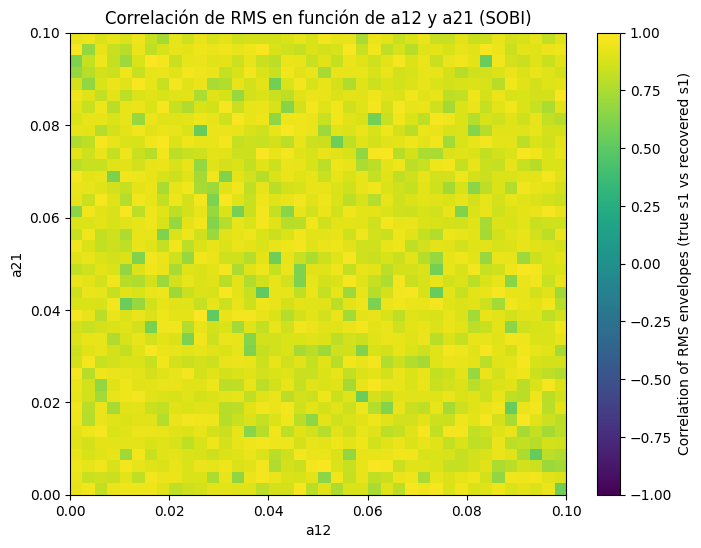

In [24]:

s1 = np.asarray(s1)
s2 = np.asarray(s2)

N = min(len(s1), len(s2))
s1 = s1[:N]
s2 = s2[:N]

S_true = np.column_stack([s1, s2])

#Barrido de parámetros
a12_values = np.linspace(0, 0.1, 40)
a11_values = np.linspace(0, 0.1, 40)

corr_map = np.zeros((len(a11_values), len(a12_values)))
print(len(corr_map))
noise_std = 0.3
window = 200

#Simulación
for i, a21 in enumerate(a11_values):
    for j, a12 in enumerate(a12_values):

        A = np.array([
            [a11,  a12],
            [0.01, 1.0]
        ])

        X = S_true @ A.T
        X = X + noise_std * np.random.randn(*X.shape)

        #SOBI
        S_est, W = sobi(X,n_sources=2, num_delays=50)

        #Alinear
        S_est = align_sources(S_est, S_true)

        #RMS envelope de la s1 original y estimada
        rms_orig_env = rms_envelope(s1, window)
        rms_est_env  = rms_envelope(S_est[:, 0], window)

        #Correlacion segura por si hay inderterminaciones
        corr = safe_corr(rms_orig_env, rms_est_env)

        corr_map[i, j] = corr


#Heatmap
plt.figure(figsize=(8, 6))

im = plt.imshow(
    corr_map,
    origin="lower",
    aspect="auto",
    extent=[a12_values[0], a12_values[-1], a11_values[0], a11_values[-1]],
    vmin=-1,
    vmax=1
)

plt.colorbar(im, label="Correlation of RMS envelopes (true s1 vs recovered s1)")
plt.xlabel("a12")
plt.ylabel("a21")
plt.title("Correlación de RMS en función de a12 y a21 (SOBI)")
plt.show()

Modelo de mezcla con retardos:
c1(t) = 1.000·s1(t) + 0.300·s2(t-5 samples)
c2(t) = 0.100·s1(t-5 samples) + 1.000·s2(t)
tau1 = 5 ms = 5 samples
tau2 = 5 ms = 5 samples

RMS fuentes verdaderas:
s1: 0.181043
s2: 0.656354

RMS mezclas:
c1: 0.286034
c2: 0.664014

=== Resultados ===
 method source     corr  corr_rms  rms_true  rms_est  rms_rel_error  rel_mae_rms_env
FastICA     s1 0.623407  0.701208  0.181043      1.0       4.523543         5.095218
FastICA     s2 0.981413  0.997185  0.656354      1.0       0.523567         0.590391
   SOBI     s1 0.469260  0.576550  0.181043      1.0       4.523543         4.988989
   SOBI     s2 0.760609  0.953825  0.656354      1.0       0.523567         0.673932

=== Comparación respecto a s1 ===
 method     corr  corr_rms  rms_true  rms_est  rms_rel_error  rel_mae_rms_env
FastICA 0.623407  0.701208  0.181043      1.0       4.523543         5.095218
   SOBI 0.469260  0.576550  0.181043      1.0       4.523543         4.988989


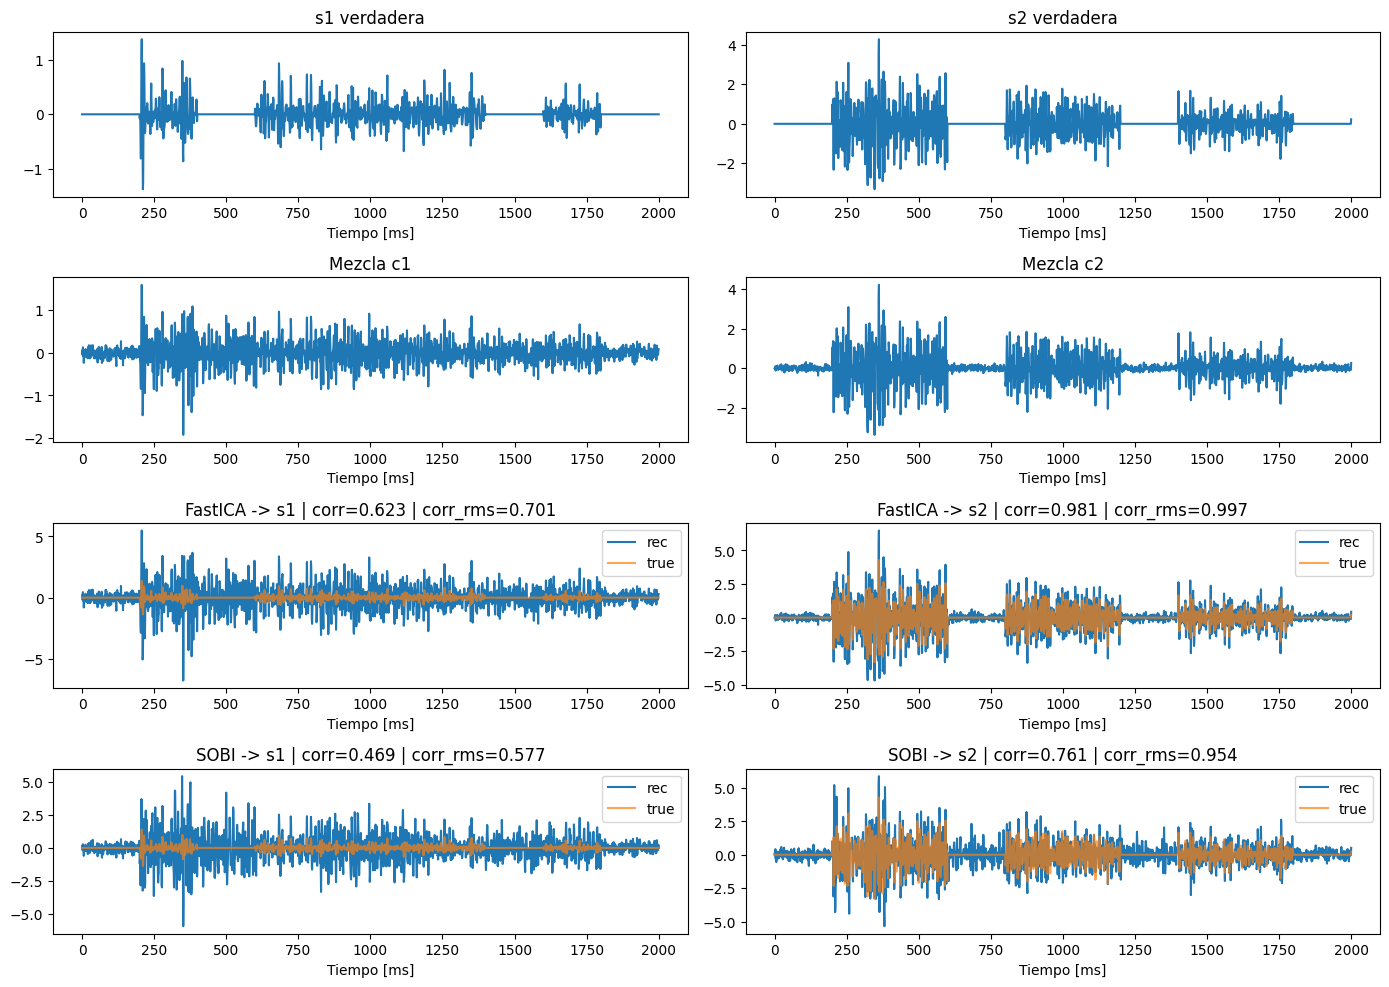

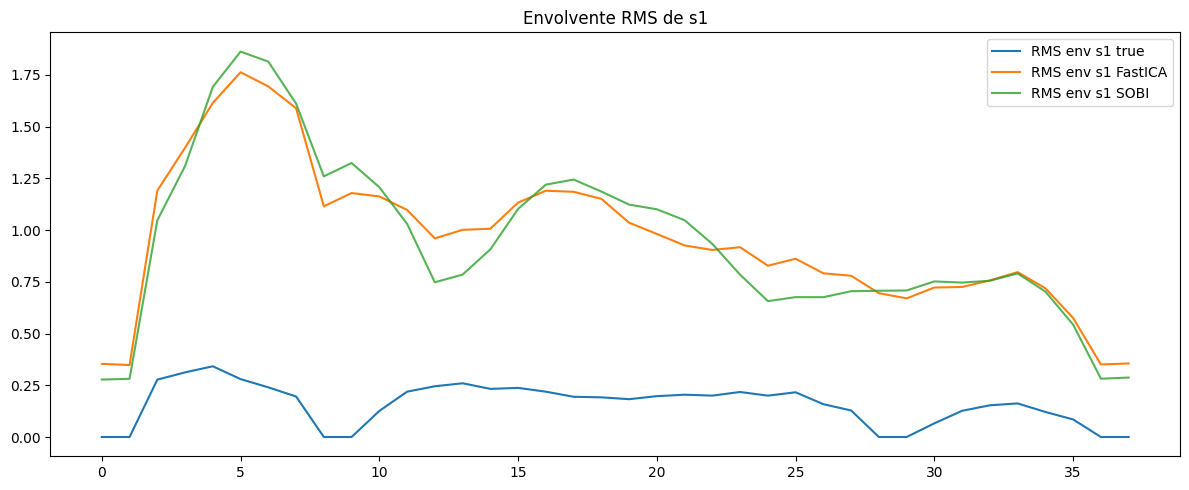

In [25]:

s1 = np.asarray(s1).ravel().astype(float)
s2 = np.asarray(s2).ravel().astype(float)

N = min(len(s1), len(s2))
s1 = s1[:N]
s2 = s2[:N]

S_true = np.column_stack([s1, s2])

#########
#Parametros
fs = 1000
window_ms = 150
step_ms = 50

beta = 0.3
a11 = 1.0
a12 = beta
a21 = 0.1
a22 = 1.0
noise_std = 0.1
seed = 0

# Retardos entre 2 y 10 ms
tau1_ms = 5  # retardo de s2 en c1
tau2_ms = 5   # retardo de s1 en c2

tau1 = int(fs * tau1_ms / 1000)
tau2 = int(fs * tau2_ms / 1000)

rng = np.random.default_rng(seed)
n = noise_std * rng.standard_normal((N, 2))

#Mezcla convolutiva
s1_delayed = delay_signal(s1, tau2)
s2_delayed = delay_signal(s2, tau1)

c1 = a11 * s1 + a12 * s2_delayed
c2 = a21 * s1_delayed + a22 * s2

X_clean = np.column_stack([c1, c2])
X = X_clean + n

print("Modelo de mezcla con retardos:")
print(f"c1(t) = {a11:.3f}·s1(t) + {a12:.3f}·s2(t-{tau1} samples)")
print(f"c2(t) = {a21:.3f}·s1(t-{tau2} samples) + {a22:.3f}·s2(t)")
print(f"tau1 = {tau1_ms} ms = {tau1} samples")
print(f"tau2 = {tau2_ms} ms = {tau2} samples")

print("\nRMS fuentes verdaderas:")
print(f"s1: {rms(s1):.6f}")
print(f"s2: {rms(s2):.6f}")

print("\nRMS mezclas:")
print(f"c1: {rms(X[:, 0]):.6f}")
print(f"c2: {rms(X[:, 1]):.6f}")

# FastICA

S_fastica, W_fastica = run_fastica(X, n_components=2, random_state=0)
df_fastica, S_fastica_eval, env_fastica = evaluate_method(
    "FastICA", S_fastica, S_true,
    fs=fs, window_ms=window_ms, step_ms=step_ms
)

# SOBI

lags = [1, 2, 3, 5, 8, 12, 16, 20, 25, 30]
S_sobi, W_sobi = sobi(X, n_sources=2, delays=lags)
df_sobi, S_sobi_eval, env_sobi = evaluate_method(
    "SOBI", S_sobi, S_true,
    fs=fs, window_ms=window_ms, step_ms=step_ms
)

#GUARDAR RESULTADOS

df_results = pd.concat([df_fastica, df_sobi], ignore_index=True)

print("\n=== Resultados ===")
print(df_results.to_string(index=False))

#RESUMEN PARA S1
df_s1 = df_results[df_results["source"] == "s1"].copy()
print("\n=== Comparación respecto a s1 ===")
print(df_s1[[
    "method", "corr", "corr_rms", "rms_true", "rms_est",
    "rms_rel_error", "rel_mae_rms_env"
]].to_string(index=False))

#Gráficas señales
num_samples_plot = min(4000, N)
t = np.arange(num_samples_plot) / fs * 1000  # en ms

plt.figure(figsize=(14, 12))

plt.subplot(5, 2, 1)
plt.plot(t, s1[:num_samples_plot])
plt.title("s1 verdadera")
plt.xlabel("Tiempo [ms]")

plt.subplot(5, 2, 2)
plt.plot(t, s2[:num_samples_plot])
plt.title("s2 verdadera")
plt.xlabel("Tiempo [ms]")



plt.subplot(5, 2, 3)
plt.plot(t, X[:num_samples_plot, 0])
plt.title("Mezcla c1")
plt.xlabel("Tiempo [ms]")

plt.subplot(5, 2, 4)
plt.plot(t, X[:num_samples_plot, 1])
plt.title("Mezcla c2")
plt.xlabel("Tiempo [ms]")

plt.subplot(5, 2, 5)
plt.plot(t, S_fastica_eval[:num_samples_plot, 0], label="rec")
plt.plot(t, s1[:num_samples_plot], alpha=0.7, label="true")
plt.title(
    f"FastICA -> s1 | corr={safe_corr(S_fastica_eval[:,0], s1):.3f} | "
    f"corr_rms={env_fastica['s1']['corr_rms']:.3f}"
)
plt.xlabel("Tiempo [ms]")
plt.legend()

plt.subplot(5, 2, 6)
plt.plot(t, S_fastica_eval[:num_samples_plot, 1], label="rec")
plt.plot(t, s2[:num_samples_plot], alpha=0.7, label="true")
plt.title(
    f"FastICA -> s2 | corr={safe_corr(S_fastica_eval[:,1], s2):.3f} | "
    f"corr_rms={env_fastica['s2']['corr_rms']:.3f}"
)
plt.xlabel("Tiempo [ms]")
plt.legend()

plt.subplot(5, 2, 7)
plt.plot(t, S_sobi_eval[:num_samples_plot, 0], label="rec")
plt.plot(t, s1[:num_samples_plot], alpha=0.7, label="true")
plt.title(
    f"SOBI -> s1 | corr={safe_corr(S_sobi_eval[:,0], s1):.3f} | "
    f"corr_rms={env_sobi['s1']['corr_rms']:.3f}"
)
plt.xlabel("Tiempo [ms]")
plt.legend()

plt.subplot(5, 2, 8)
plt.plot(t, S_sobi_eval[:num_samples_plot, 1], label="rec")
plt.plot(t, s2[:num_samples_plot], alpha=0.7, label="true")
plt.title(
    f"SOBI -> s2 | corr={safe_corr(S_sobi_eval[:,1], s2):.3f} | "
    f"corr_rms={env_sobi['s2']['corr_rms']:.3f}"
)
plt.xlabel("Tiempo [ms]")
plt.legend()

plt.tight_layout()
plt.show()

# =========================================================
# Gráficas de envolvente RMS para s1
# =========================================================
plt.figure(figsize=(12, 5))
plt.plot(env_fastica["s1"]["env_true"], label="RMS env s1 true")
plt.plot(env_fastica["s1"]["env_est"], label="RMS env s1 FastICA")
plt.plot(env_sobi["s1"]["env_est"], label="RMS env s1 SOBI", alpha=0.8)
plt.title("Envolvente RMS de s1")
plt.legend()
plt.tight_layout()
plt.show()

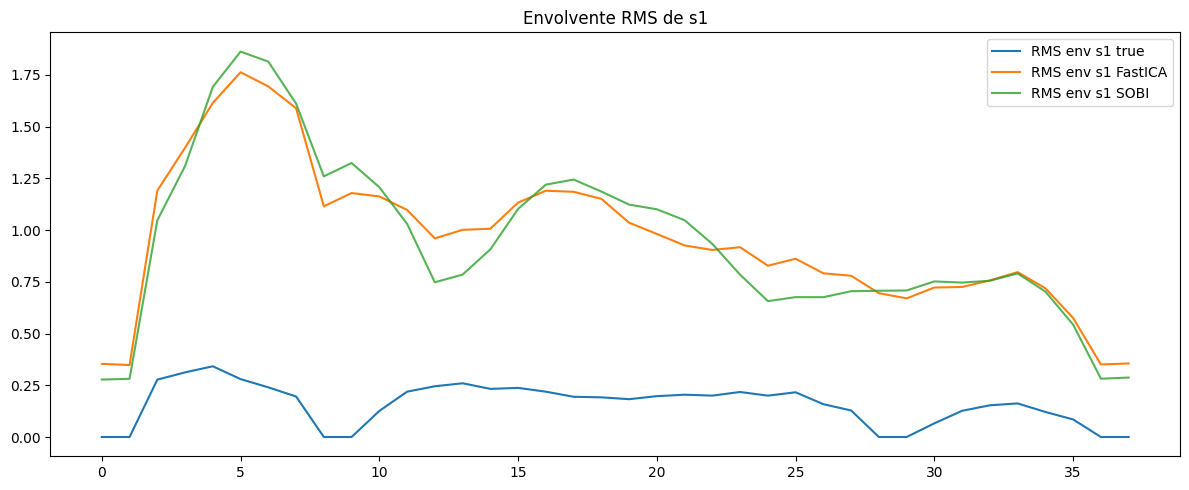

In [26]:
#Grafica de envolventes RMS
plt.figure(figsize=(12, 5))
plt.plot(env_fastica["s1"]["env_true"], label="RMS env s1 true")
plt.plot(env_fastica["s1"]["env_est"], label="RMS env s1 FastICA")
plt.plot(env_sobi["s1"]["env_est"], label="RMS env s1 SOBI", alpha=0.8)
plt.title("Envolvente RMS de s1")
plt.legend()
plt.tight_layout()
plt.show()

## CASO OPTIMO SOBI

Estructura temporal diferente, aka mirar autocorrelacion

### Autocorrelacion base original

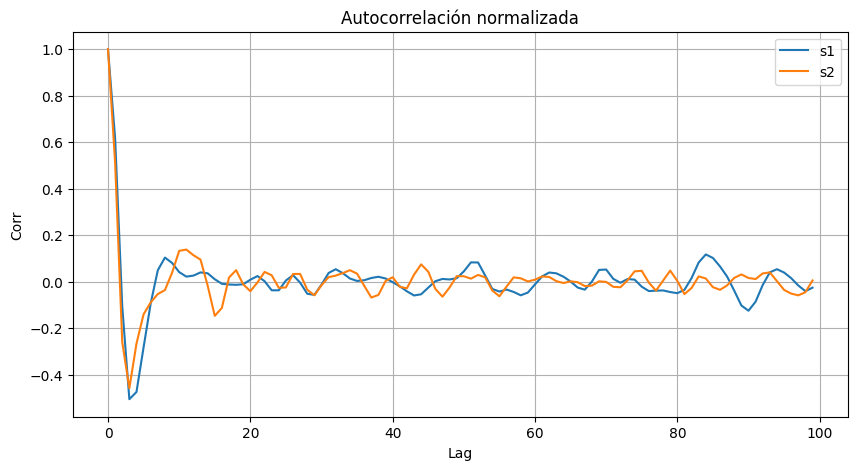

Lag 1: s1=0.617, s2=0.511
Lag 2: s1=-0.106, s2=-0.260
Lag 5: s1=-0.282, s2=-0.140
Lag 10: s1=0.041, s2=0.133
Lag 20: s1=0.009, s2=-0.041


In [27]:
r1 = autocorr_norm(s1)
r2 = autocorr_norm(s2)

lags = np.arange(len(r1))

plt.figure(figsize=(10,5))
plt.plot(lags[:100], r1[:100], label='s1')
plt.plot(lags[:100], r2[:100], label='s2')
plt.title("Autocorrelación normalizada")
plt.xlabel("Lag")
plt.ylabel("Corr")
plt.legend()
plt.grid()
plt.show()

for lag in [1, 2, 5, 10, 20]:
    r1 = np.corrcoef(s1[:-lag], s1[lag:])[0,1]
    r2 = np.corrcoef(s2[:-lag], s2[lag:])[0,1]
    print(f"Lag {lag}: s1={r1:.3f}, s2={r2:.3f}")

## Considerar músculos en ubicaciones diferentes. Brazo vs pecho simulado


Modelo de mezcla con retardos:
c1(t) = 1.000·s1(t) + 0.800·s2(t-10 samples)
c2(t) = 0.010·s1(t-10 samples) + 1.000·s2(t)
tau1 = 10 ms = 10 samples
tau2 = 10 ms = 10 samples

RMS fuentes verdaderas:
s1: 0.177464
s2: 0.199794

RMS mezclas:
c1: 0.259155
c2: 0.224295

=== Resultados ===
 method source     corr  corr_rms  rms_true  rms_est  rms_rel_error  rel_mae_rms_env
FastICA     s1 0.707674  0.758858  0.177464      1.0       4.634940         5.371494
FastICA     s2 0.896881  0.988569  0.199794      1.0       4.005159         4.543208
   SOBI     s1 0.691042  0.728979  0.177464      1.0       4.634940         5.385514
   SOBI     s2 0.884629  0.986765  0.199794      1.0       4.005159         4.552360

=== Comparación respecto a s1 ===
 method     corr  corr_rms  rms_true  rms_est  rms_rel_error  rel_mae_rms_env
FastICA 0.707674  0.758858  0.177464      1.0        4.63494         5.371494
   SOBI 0.691042  0.728979  0.177464      1.0        4.63494         5.385514


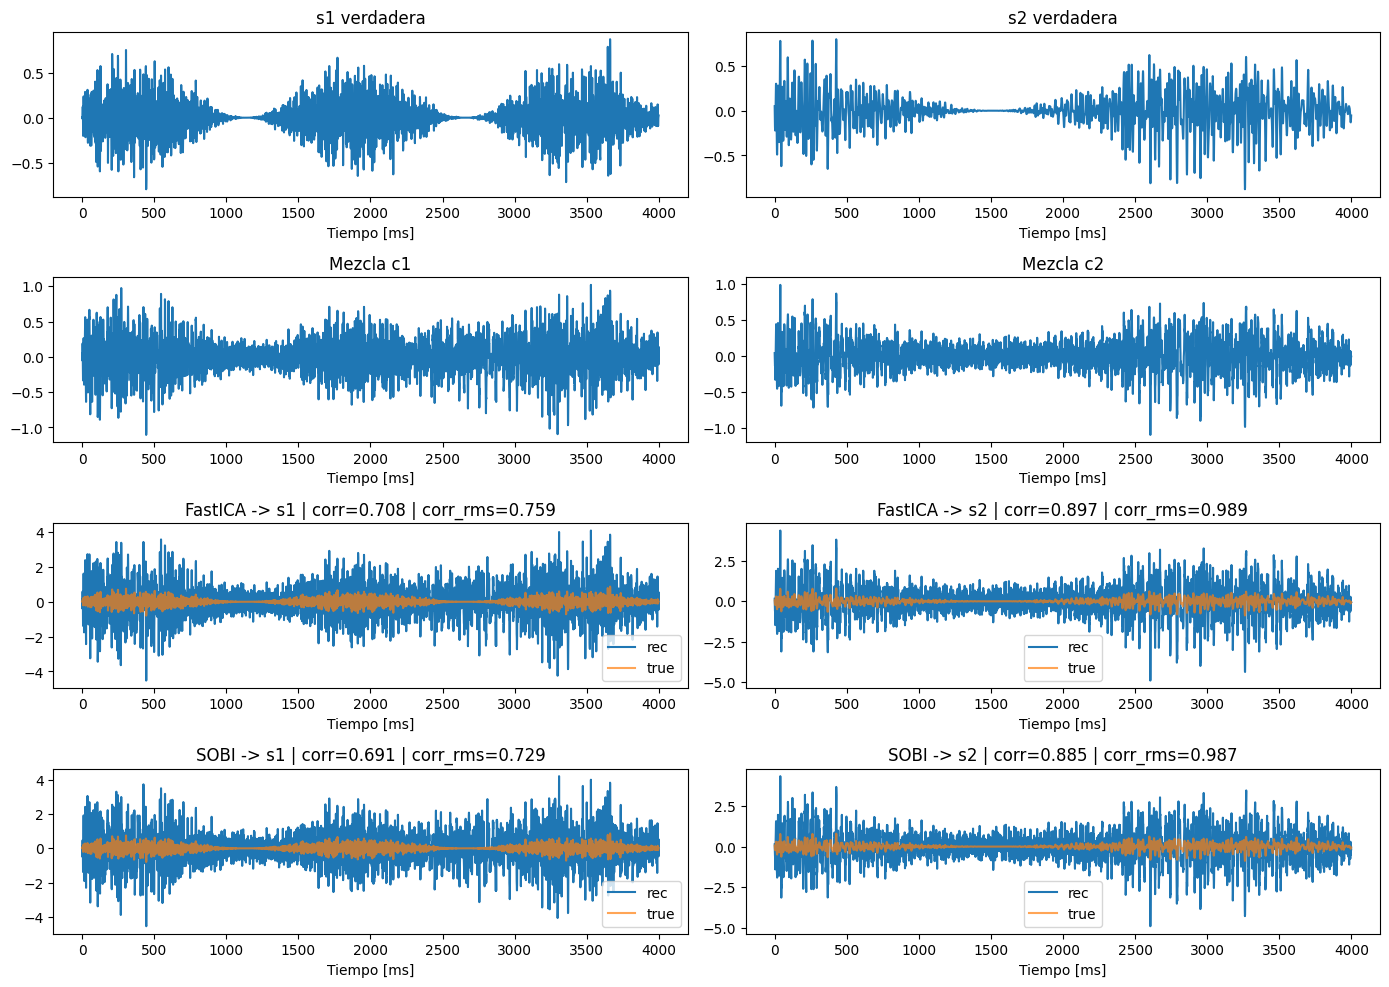

In [28]:

# =========================================================
#Señales artificiales con retardos
fs = 1000 
duracion = 10  
t = np.arange(0, duracion, 1/fs)
N = len(t)

# --- s1: Señal del Brazo (Bíceps) ---
#Frecuencias más altas, pico ~100-150Hz
raw_s1 = np.random.normal(0, 1, N)
#paso banda
b1, a1 = signal.butter(4, [60, 250], btype='bandpass', fs=fs)
s1 = signal.filtfilt(b1, a1, raw_s1)
#envolvente con rafagas de 1.5
env1 = 0.5 * (1 + np.sin(2 * np.pi * 0.66 * t)) 
s1 *= env1

# --- s2: Señal del Pectoral ---
#Frecuencias más bajas, pico ~30-70Hz (más lenta)
raw_s2 = np.random.normal(0, 1, N)
# paso banda entre 20 y 90 Hz
b2, a2 = signal.butter(4, [20, 90], btype='bandpass', fs=fs)
s2 = signal.filtfilt(b2, a2, raw_s2)
# Envolvente con cilcos de 3 segundos
env2 = 0.5 * (1 + np.cos(2 * np.pi * 0.33 * t))
s2 *= env2

#Normalizar
s1 = s1 / np.max(np.abs(s1))
s2 = s2 / np.max(np.abs(s2))

S_true = np.column_stack([s1, s2])

#Parametros
fs = 1000
window_ms = 150
step_ms = 50

beta = 0.8
a11 = 1.0
a12 = beta
a21 = 0.01
a22 = 1.0
noise_std = 0.1
seed = 0


tau1_ms = 10  
tau2_ms = 10   

tau1 = int(fs * tau1_ms / 1000)
tau2 = int(fs * tau2_ms / 1000)

rng = np.random.default_rng(seed)
n = noise_std * rng.standard_normal((N, 2))

#MEZCLA CONVOLUTIVA
s1_delayed = delay_signal(s1, tau2)
s2_delayed = delay_signal(s2, tau1)

c1 = a11 * s1 + a12 * s2_delayed
c2 = a21 * s1_delayed + a22 * s2

X_clean = np.column_stack([c1, c2])
X = X_clean + n

print("Modelo de mezcla con retardos:")
print(f"c1(t) = {a11:.3f}·s1(t) + {a12:.3f}·s2(t-{tau1} samples)")
print(f"c2(t) = {a21:.3f}·s1(t-{tau2} samples) + {a22:.3f}·s2(t)")
print(f"tau1 = {tau1_ms} ms = {tau1} samples")
print(f"tau2 = {tau2_ms} ms = {tau2} samples")

print("\nRMS fuentes verdaderas:")
print(f"s1: {rms(s1):.6f}")
print(f"s2: {rms(s2):.6f}")

print("\nRMS mezclas:")
print(f"c1: {rms(X[:, 0]):.6f}")
print(f"c2: {rms(X[:, 1]):.6f}")

#FASTICA
S_fastica, W_fastica = run_fastica(X, n_components=2, random_state=0)
df_fastica, S_fastica_eval, env_fastica = evaluate_method(
    "FastICA", S_fastica, S_true,
    fs=fs, window_ms=window_ms, step_ms=step_ms
)

#SOBI
lags = [1, 2, 3, 5, 8, 12, 16, 20, 25, 30]
S_sobi, W_sobi = sobi(X, n_sources=2, delays=lags)
df_sobi, S_sobi_eval, env_sobi = evaluate_method(
    "SOBI", S_sobi, S_true,
    fs=fs, window_ms=window_ms, step_ms=step_ms
)

#RESULTADOS
df_results = pd.concat([df_fastica, df_sobi], ignore_index=True)

print("\n=== Resultados ===")
print(df_results.to_string(index=False))

#Resumen para s1
df_s1 = df_results[df_results["source"] == "s1"].copy()
print("\n=== Comparación respecto a s1 ===")
print(df_s1[[
    "method", "corr", "corr_rms", "rms_true", "rms_est",
    "rms_rel_error", "rel_mae_rms_env"
]].to_string(index=False))

#Gráficas señales
num_samples_plot = min(4000, N)
t = np.arange(num_samples_plot) / fs * 1000  # en ms

plt.figure(figsize=(14, 12))

plt.subplot(5, 2, 1)
plt.plot(t, s1[:num_samples_plot])
plt.title("s1 verdadera")
plt.xlabel("Tiempo [ms]")

plt.subplot(5, 2, 2)
plt.plot(t, s2[:num_samples_plot])
plt.title("s2 verdadera")
plt.xlabel("Tiempo [ms]")



plt.subplot(5, 2, 3)
plt.plot(t, X[:num_samples_plot, 0])
plt.title("Mezcla c1")
plt.xlabel("Tiempo [ms]")

plt.subplot(5, 2, 4)
plt.plot(t, X[:num_samples_plot, 1])
plt.title("Mezcla c2")
plt.xlabel("Tiempo [ms]")

plt.subplot(5, 2, 5)
plt.plot(t, S_fastica_eval[:num_samples_plot, 0], label="rec")
plt.plot(t, s1[:num_samples_plot], alpha=0.7, label="true")
plt.title(
    f"FastICA -> s1 | corr={safe_corr(S_fastica_eval[:,0], s1):.3f} | "
    f"corr_rms={env_fastica['s1']['corr_rms']:.3f}"
)
plt.xlabel("Tiempo [ms]")
plt.legend()

plt.subplot(5, 2, 6)
plt.plot(t, S_fastica_eval[:num_samples_plot, 1], label="rec")
plt.plot(t, s2[:num_samples_plot], alpha=0.7, label="true")
plt.title(
    f"FastICA -> s2 | corr={safe_corr(S_fastica_eval[:,1], s2):.3f} | "
    f"corr_rms={env_fastica['s2']['corr_rms']:.3f}"
)
plt.xlabel("Tiempo [ms]")
plt.legend()

plt.subplot(5, 2, 7)
plt.plot(t, S_sobi_eval[:num_samples_plot, 0], label="rec")
plt.plot(t, s1[:num_samples_plot], alpha=0.7, label="true")
plt.title(
    f"SOBI -> s1 | corr={safe_corr(S_sobi_eval[:,0], s1):.3f} | "
    f"corr_rms={env_sobi['s1']['corr_rms']:.3f}"
)
plt.xlabel("Tiempo [ms]")
plt.legend()

plt.subplot(5, 2, 8)
plt.plot(t, S_sobi_eval[:num_samples_plot, 1], label="rec")
plt.plot(t, s2[:num_samples_plot], alpha=0.7, label="true")
plt.title(
    f"SOBI -> s2 | corr={safe_corr(S_sobi_eval[:,1], s2):.3f} | "
    f"corr_rms={env_sobi['s2']['corr_rms']:.3f}"
)
plt.xlabel("Tiempo [ms]")
plt.legend()

plt.tight_layout()
plt.show()

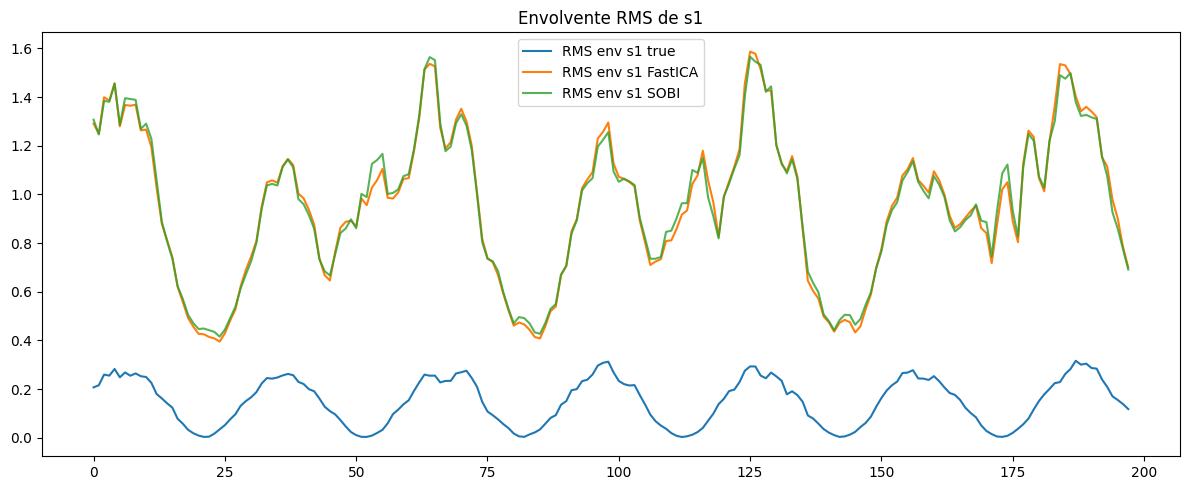

In [29]:
plt.figure(figsize=(12, 5))
plt.plot(env_fastica["s1"]["env_true"], label="RMS env s1 true")
plt.plot(env_fastica["s1"]["env_est"], label="RMS env s1 FastICA")
plt.plot(env_sobi["s1"]["env_est"], label="RMS env s1 SOBI", alpha=0.8)
plt.title("Envolvente RMS de s1")
plt.legend()
plt.tight_layout()
plt.show()

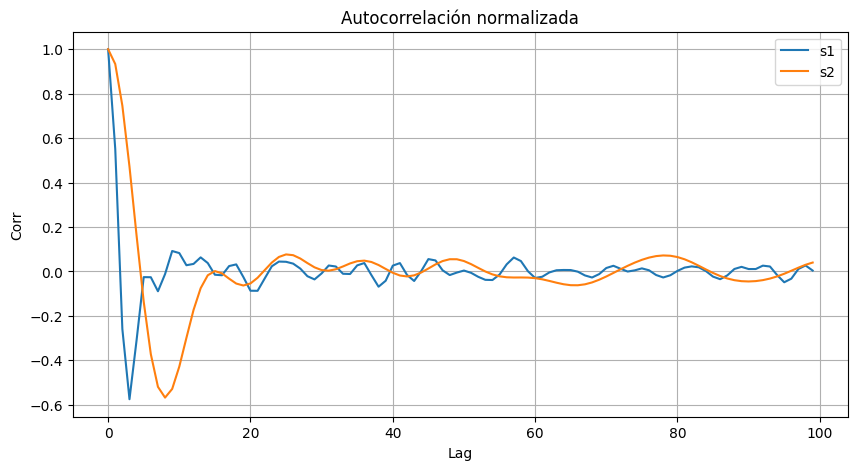

Lag 1: s1=0.551, s2=0.933
Lag 2: s1=-0.260, s2=0.746
Lag 5: s1=-0.026, s2=-0.136
Lag 10: s1=0.083, s2=-0.429
Lag 20: s1=-0.087, s2=-0.054


In [30]:
r1 = autocorr_norm(s1)
r2 = autocorr_norm(s2)

lags = np.arange(len(r1))

plt.figure(figsize=(10,5))
plt.plot(lags[:100], r1[:100], label='s1')
plt.plot(lags[:100], r2[:100], label='s2')
plt.title("Autocorrelación normalizada")
plt.xlabel("Lag")
plt.ylabel("Corr")
plt.legend()
plt.grid()
plt.show()

for lag in [1, 2, 5, 10, 20]:
    r1 = np.corrcoef(s1[:-lag], s1[lag:])[0,1]
    r2 = np.corrcoef(s2[:-lag], s2[lag:])[0,1]
    print(f"Lag {lag}: s1={r1:.3f}, s2={r2:.3f}")